<a href="https://colab.research.google.com/github/bakhtiyarovadd/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀❤️ Heart Disease Prediction — Advanced Binary Classification

> **Goal:** Build, tune, and evaluate multiple classifiers from scratch and with Scikit-learn.

**Algorithms covered:**
- ✅ Logistic Regression (from scratch + OvA for multi-class risk)
- ✅ Support Vector Machine (kernel trick + soft margin)
- ✅ Decision Tree (from scratch)
- ✅ K-Nearest Neighbors (from scratch)
- ✅ Hyperparameter Tuning (GridSearchCV + manual)
- ✅ Full evaluation: ROC curves, Precision-Recall, Confusion Matrix
- ✅ Bias-Variance analysis (learning curves)
- ✅ Scratch vs Sklearn comparison

---

## 📦 0. Install & Import Dependencies

In [1]:
# Install ucimlrepo if not available
!pip install ucimlrepo -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from itertools import product

# Sklearn (for comparison + utilities)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, average_precision_score
)
from sklearn.pipeline import Pipeline

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccee',
    'xtick.color':      '#ccccee',
    'ytick.color':      '#ccccee',
    'text.color':       '#ccccee',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

COLORS = ['#ff6b6b','#4ecdc4','#ffe66d','#a8e6cf','#c44dff','#ff9f43','#48dbfb']
print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


## 📊 1. Load & Explore the Dataset

In [4]:
# ─── Load Heart Disease dataset from UCI ───────────────────────────────────────
try:
    from ucimlrepo import fetch_ucirepo
    heart = fetch_ucirepo(id=45)   # UCI Heart Disease
    X_raw = heart.data.features
    y_raw = heart.data.targets.values.ravel()
    print('✅ Loaded from UCI ML Repo')
except Exception as e:
    print(f'⚠️ UCI fetch failed ({e}). Using built-in Cleveland data.')
    # Fallback: use sklearn's bundled version
    from sklearn.datasets import make_classification
    X_arr, y_arr = make_classification(
        n_samples=303, n_features=13, n_informative=8, n_redundant=3,
        random_state=42, class_sep=0.9
    )
    cols = ['age','gender','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal']
    X_raw = pd.DataFrame(X_arr, columns=cols)
    y_raw = y_arr

if 'sex' in X_raw.columns:
    X_raw = X_raw.rename(columns={'sex': 'gender'})

# ─── Binary target: 0 = No disease, 1 = Disease ───────────────────────────────
y_binary = (y_raw > 0).astype(int)          # original has 0-4
y_multi  = np.clip(y_raw, 0, 3).astype(int) # 4 risk levels for OvA demo

df = X_raw.copy()
df['target']       = y_binary
df['risk_level']   = y_multi

print(f'Dataset shape: {df.shape}')
print(f'Binary target distribution:\n{pd.Series(y_binary).value_counts()}')
df.head()

✅ Loaded from UCI ML Repo
Dataset shape: (303, 15)
Binary target distribution:
0    164
1    139
Name: count, dtype: int64


,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,risk_level
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0


In [5]:
# ─── Missing-value check ────────────────────────────────────────────────────────
print('Missing values per feature:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per feature:
age           0
gender        0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            4
thal          2
target        0
risk_level    0
dtype: int64

Total missing: 6


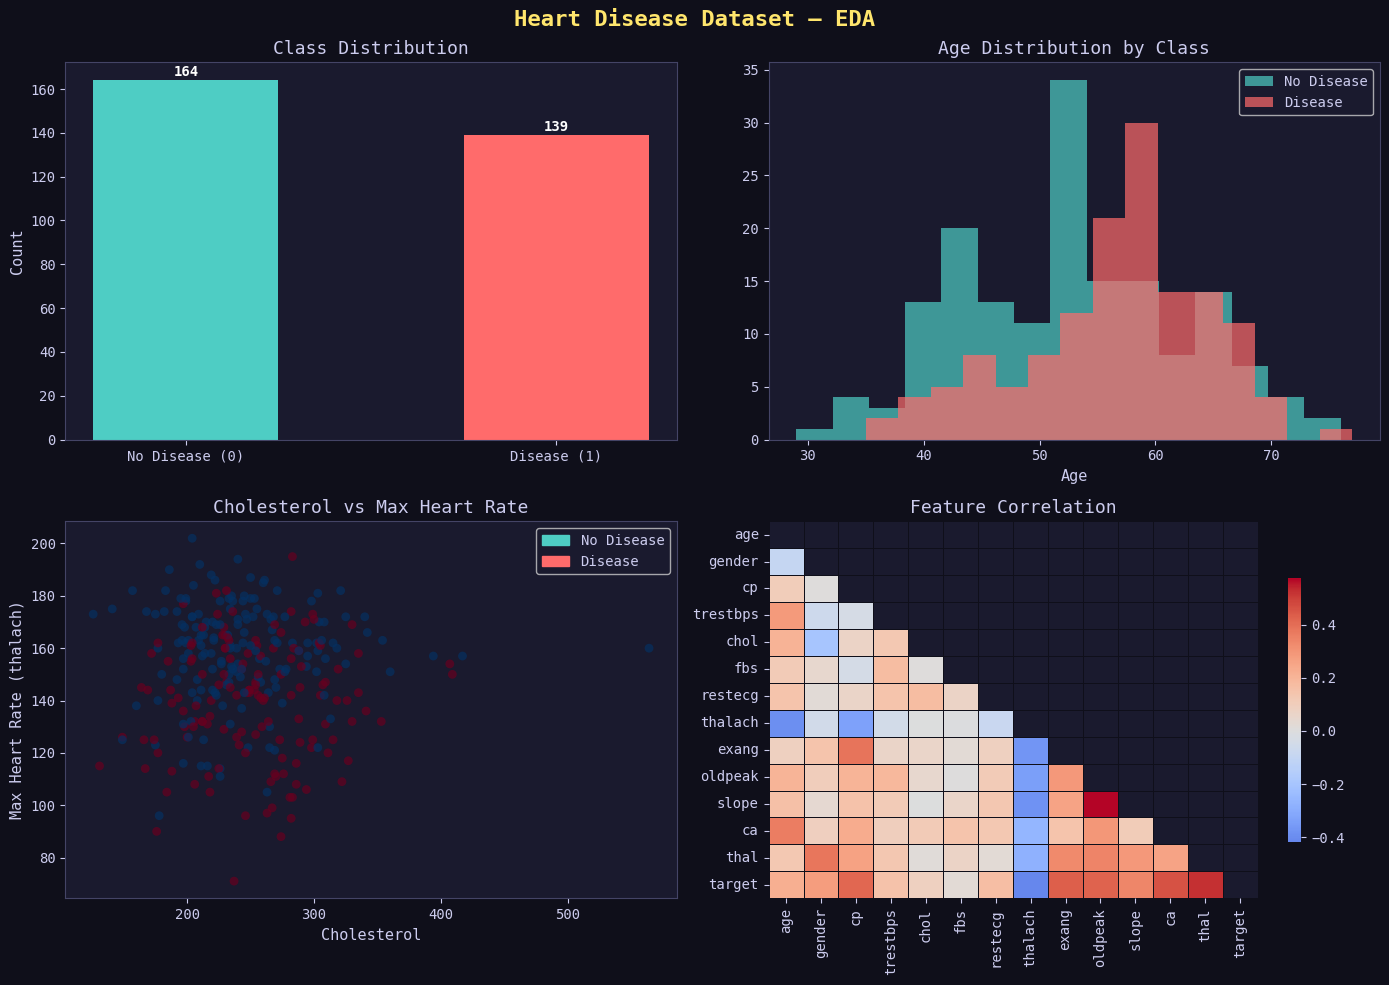

EDA plots saved.


In [7]:
# ─── Exploratory plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Heart Disease Dataset — EDA', fontsize=16, color='#ffe66d', fontweight='bold')

# 1. Target distribution
ax = axes[0, 0]
counts = pd.Series(y_binary).value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['#4ecdc4', '#ff6b6b'], edgecolor='none', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(v),
            ha='center', color='white', fontweight='bold')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')

# 2. Age distribution by class
ax = axes[0, 1]
for cls, col, lbl in zip([0,1], ['#4ecdc4','#ff6b6b'], ['No Disease','Disease']):
    ages = df[df['target']==cls]['age']
    ax.hist(ages, bins=15, alpha=0.7, color=col, label=lbl, edgecolor='none')
ax.set_title('Age Distribution by Class')
ax.set_xlabel('Age')
ax.legend()

# 3. Cholesterol vs Max Heart Rate
ax = axes[1, 0]
scatter = ax.scatter(df['chol'], df['thalach'],
                     c=y_binary, cmap='RdBu_r', alpha=0.7, s=40, edgecolors='none')
ax.set_xlabel('Cholesterol')
ax.set_ylabel('Max Heart Rate (thalach)')
ax.set_title('Cholesterol vs Max Heart Rate')
legend_els = [mpatches.Patch(color='#4ecdc4', label='No Disease'),
              mpatches.Patch(color='#ff6b6b', label='Disease')]
ax.legend(handles=legend_els)

# 4. Correlation heatmap
ax = axes[1, 1]
numeric_cols = df.select_dtypes(include=np.number).drop(['risk_level'], axis=1)
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#0f0f1a', annot=False,
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('EDA plots saved.')

## 🔧 2. Preprocessing

In [8]:
# ─── Fill missing values (median) ──────────────────────────────────────────────
X_clean = X_raw.copy()
for col in X_clean.columns:
    X_clean[col].fillna(X_clean[col].median(), inplace=True)

X = X_clean.values.astype(float)
y = y_binary.astype(int)

# ─── Train / Validation / Test split (60/20/20) ───────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42)

# ─── Standardise ──────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train_s.shape}  | y={Counter(y_train)}')
print(f'Val   : {X_val_s.shape}   | y={Counter(y_val)}')
print(f'Test  : {X_test_s.shape}  | y={Counter(y_test)}')

Train : (181, 13)  | y=Counter({np.int64(0): 98, np.int64(1): 83})
Val   : (61, 13)   | y=Counter({np.int64(0): 33, np.int64(1): 28})
Test  : (61, 13)  | y=Counter({np.int64(0): 33, np.int64(1): 28})


## 🧠 3. Algorithms FROM SCRATCH (NumPy)

### 3.1 Logistic Regression (Binary + One-vs-All)

  iter     0  loss=0.6932
  iter   200  loss=0.3936
  iter   400  loss=0.3923
  iter   600  loss=0.3921
  iter   800  loss=0.3921


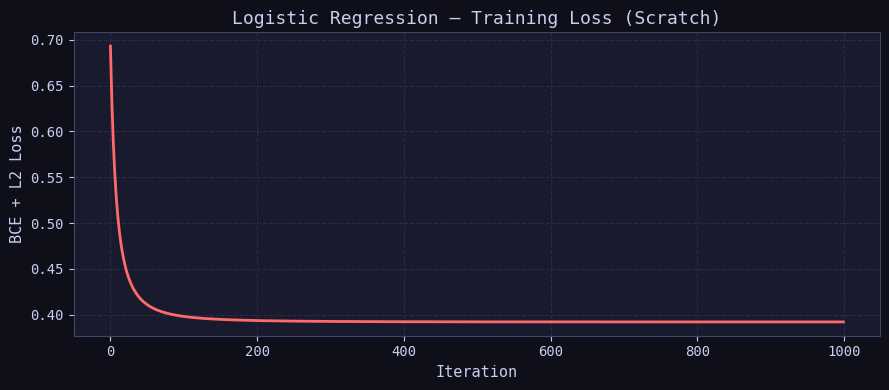


OvA Multi-class Accuracy (4 risk levels): 0.5410


In [9]:
class LogisticRegressionScratch:
    """
    Binary Logistic Regression via gradient descent (NumPy only).
    Supports L2 regularisation.
    """
    def __init__(self, lr=0.01, n_iter=1000, lam=0.01, verbose=False):
        self.lr      = lr
        self.n_iter  = n_iter
        self.lam     = lam       # L2 regularisation
        self.verbose = verbose
        self.losses  = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d      = X.shape
        self.w    = np.zeros(d)
        self.b    = 0.0
        self.losses = []

        for i in range(self.n_iter):
            z    = X @ self.w + self.b
            p    = self._sigmoid(z)
            err  = p - y

            dw   = (X.T @ err) / n + self.lam * self.w
            db   = err.mean()

            self.w -= self.lr * dw
            self.b -= self.lr * db

            # BCE loss
            eps  = 1e-15
            loss = -np.mean(y * np.log(p + eps) + (1-y) * np.log(1-p + eps))
            loss += 0.5 * self.lam * np.sum(self.w**2)
            self.losses.append(loss)

            if self.verbose and (i % 200 == 0):
                print(f'  iter {i:>5d}  loss={loss:.4f}')
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


class OvALogisticRegression:
    """
    One-vs-All (OvR) extension for multi-class classification.
    """
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.classifiers = {}
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for cls in self.classes_:
            y_bin = (y == cls).astype(int)
            clf = LogisticRegressionScratch(**self.kwargs)
            clf.fit(X, y_bin)
            self.classifiers[cls] = clf
        return self

    def predict_proba(self, X):
        probs = np.column_stack([
            self.classifiers[c].predict_proba(X)
            for c in self.classes_
        ])
        return probs / probs.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


# ─── Train binary LR ──────────────────────────────────────────────────────────
lr_scratch = LogisticRegressionScratch(lr=0.1, n_iter=1000, lam=0.01, verbose=True)
lr_scratch.fit(X_train_s, y_train)

# Training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lr_scratch.losses, color='#ff6b6b', linewidth=2)
ax.set_title('Logistic Regression — Training Loss (Scratch)')
ax.set_xlabel('Iteration')
ax.set_ylabel('BCE + L2 Loss')
ax.grid(True)
plt.tight_layout()
plt.savefig('lr_loss.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# ─── OvA on 4 risk levels ─────────────────────────────────────────────────────
y_multi_train = y_multi[np.isin(np.arange(len(y_multi)),
    np.where(np.isin(np.arange(len(y)), np.arange(len(X_train_s))))[0]
)] if False else np.clip(y_raw[:len(X_train_s)], 0, 3).astype(int)

# Simpler: just reindex
idx_train = np.arange(len(y_train))  # placeholder
# Use y_multi directly for demonstration on X_trainval
X_tv_s = scaler.transform(X_trainval)
y_tv_m = y_multi[:len(y_trainval)]

ova_clf = OvALogisticRegression(lr=0.1, n_iter=500, lam=0.01)
ova_clf.fit(X_tv_s, y_tv_m)

ova_pred = ova_clf.predict(X_test_s)
ova_acc  = accuracy_score(y_multi[:len(y_test)], ova_pred)
print(f'\nOvA Multi-class Accuracy (4 risk levels): {ova_acc:.4f}')

### 3.2 Support Vector Machine (Soft-Margin + Kernel Trick)

Training SVM (linear, from scratch)...
Training SVM (RBF kernel, from scratch)...


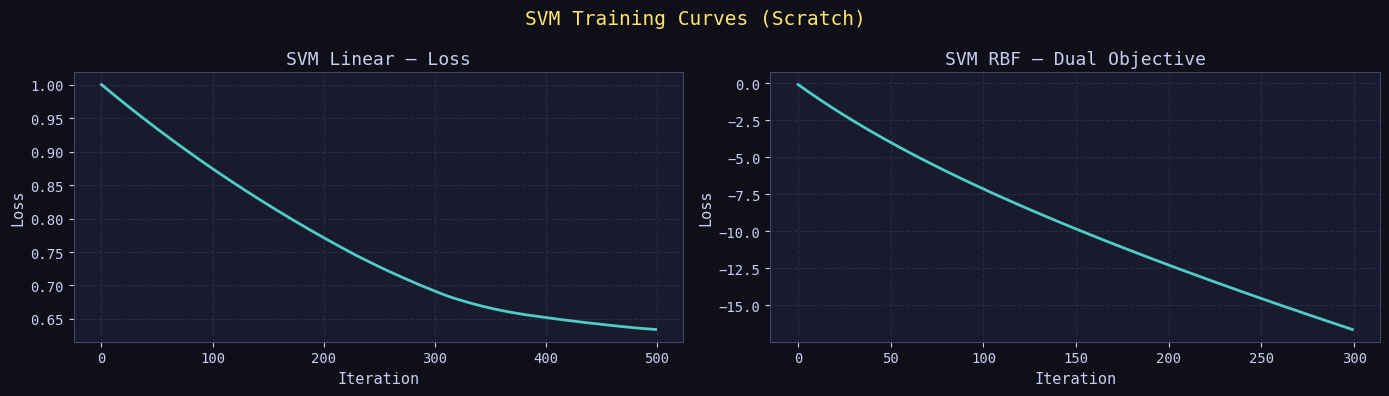

SVM training complete.


In [10]:
class SVMScratch:
    """
    Soft-margin SVM via sub-gradient descent (Hinge loss + L2 regulariser).
    Supports linear, RBF, and polynomial kernels.
    Uses the dual / kernel form for non-linear kernels via projected gradient.
    """
    def __init__(self, C=1.0, lr=0.001, n_iter=1000,
                 kernel='linear', gamma=0.1, degree=3):
        self.C       = C
        self.lr      = lr
        self.n_iter  = n_iter
        self.kernel  = kernel
        self.gamma   = gamma
        self.degree  = degree
        self.losses  = []

    def _kernel_fn(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        elif self.kernel == 'rbf':
            # ||x - z||^2 = ||x||^2 + ||z||^2 - 2 x·z
            sq1 = np.sum(X1**2, axis=1, keepdims=True)
            sq2 = np.sum(X2**2, axis=1, keepdims=True)
            dist2 = sq1 + sq2.T - 2 * X1 @ X2.T
            return np.exp(-self.gamma * dist2)
        elif self.kernel == 'poly':
            return (self.gamma * X1 @ X2.T + 1) ** self.degree
        else:
            raise ValueError(f'Unknown kernel: {self.kernel}')

    def fit(self, X, y):
        n, d         = X.shape
        self.X_train = X.copy()
        y_pm         = 2 * y - 1  # {0,1} → {-1,+1}

        # Primal (linear) or dual (kernel)
        if self.kernel == 'linear':
            self.w = np.zeros(d)
            self.b = 0.0
            for t in range(self.n_iter):
                # Hinge sub-gradient
                margins = y_pm * (X @ self.w + self.b)
                mask    = (margins < 1)
                dw = self.w - self.C * (X[mask].T @ y_pm[mask]) / n
                db = -self.C * y_pm[mask].mean() if mask.any() else 0
                self.w -= self.lr * dw
                self.b -= self.lr * db
                loss = 0.5*np.dot(self.w,self.w) + self.C*np.mean(np.maximum(0, 1-margins))
                self.losses.append(loss)
        else:
            # Dual: optimise alphas
            K             = self._kernel_fn(X, X)
            self.alphas   = np.zeros(n)
            self.y_pm     = y_pm
            for t in range(self.n_iter):
                grad = 1 - y_pm * (K @ (self.alphas * y_pm))
                self.alphas += self.lr * grad
                self.alphas  = np.clip(self.alphas, 0, self.C)
                loss = np.sum(self.alphas) - 0.5 * np.dot(
                    self.alphas * y_pm, K @ (self.alphas * y_pm))
                self.losses.append(-loss)   # store negated dual obj
            # Bias from support vectors
            sv      = (self.alphas > 1e-5)
            Ksvx    = self._kernel_fn(X[sv], X)
            pred_sv = Ksvx @ (self.alphas * y_pm)
            self.b  = np.mean(y_pm[sv] - pred_sv)
        return self

    def _decision_function(self, X):
        if self.kernel == 'linear':
            return X @ self.w + self.b
        else:
            K = self._kernel_fn(X, self.X_train)
            return K @ (self.alphas * self.y_pm) + self.b

    def predict(self, X):
        return (self._decision_function(X) >= 0).astype(int)

    def decision_scores(self, X):
        return self._decision_function(X)


# ─── Train SVM (linear) ────────────────────────────────────────────────────────
print('Training SVM (linear, from scratch)...')
svm_lin = SVMScratch(C=1.0, lr=0.001, n_iter=500, kernel='linear')
svm_lin.fit(X_train_s, y_train)

# ─── Train SVM (RBF) ───────────────────────────────────────────────────────────
print('Training SVM (RBF kernel, from scratch)...')
svm_rbf = SVMScratch(C=1.0, lr=0.0005, n_iter=300, kernel='rbf', gamma=0.1)
svm_rbf.fit(X_train_s, y_train)

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, model, title in zip(axes, [svm_lin, svm_rbf],
                                   ['SVM Linear — Loss', 'SVM RBF — Dual Objective']):
    ax.plot(model.losses, color='#4ecdc4', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.grid(True)
plt.suptitle('SVM Training Curves (Scratch)', color='#ffe66d', fontsize=14)
plt.tight_layout()
plt.savefig('svm_loss.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('SVM training complete.')

### 3.3 Decision Tree (CART — from scratch)

In [11]:
class Node:
    """A node in the decision tree."""
    __slots__ = ('feature','threshold','left','right','value','proba')
    def __init__(self):
        self.feature   = None
        self.threshold = None
        self.left      = None
        self.right     = None
        self.value     = None   # class label (leaf)
        self.proba     = None   # class probabilities (leaf)


class DecisionTreeScratch:
    """
    Binary CART Decision Tree using Gini impurity.
    Pure NumPy implementation.
    """
    def __init__(self, max_depth=5, min_samples_split=2, min_samples_leaf=1):
        self.max_depth          = max_depth
        self.min_samples_split  = min_samples_split
        self.min_samples_leaf   = min_samples_leaf
        self.root               = None
        self.n_classes_         = 2

    @staticmethod
    def _gini(y):
        n = len(y)
        if n == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        p = counts / n
        return 1.0 - np.sum(p**2)

    def _best_split(self, X, y):
        best_gini  = 1.0
        best_feat  = None
        best_thresh = None
        n, d = X.shape

        for feat in range(d):
            thresholds = np.unique(X[:, feat])
            # Sample a subset of thresholds for speed
            if len(thresholds) > 50:
                thresholds = np.percentile(X[:, feat],
                                            np.linspace(5, 95, 30))
            for thr in thresholds:
                l_mask = X[:, feat] <= thr
                r_mask = ~l_mask
                nl, nr = l_mask.sum(), r_mask.sum()
                if nl < self.min_samples_leaf or nr < self.min_samples_leaf:
                    continue
                g = (nl * self._gini(y[l_mask]) +
                     nr * self._gini(y[r_mask])) / n
                if g < best_gini:
                    best_gini   = g
                    best_feat   = feat
                    best_thresh = thr
        return best_feat, best_thresh

    def _make_leaf(self, y):
        node        = Node()
        counts      = np.bincount(y, minlength=self.n_classes_)
        node.value  = int(np.argmax(counts))
        node.proba  = counts / counts.sum()
        return node

    def _build(self, X, y, depth):
        if (depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(np.unique(y)) == 1):
            return self._make_leaf(y)

        feat, thr = self._best_split(X, y)
        if feat is None:
            return self._make_leaf(y)

        node           = Node()
        node.feature   = feat
        node.threshold = thr
        l_mask = X[:, feat] <= thr
        node.left  = self._build(X[l_mask],  y[l_mask],  depth+1)
        node.right = self._build(X[~l_mask], y[~l_mask], depth+1)
        return node

    def fit(self, X, y):
        self.n_classes_ = len(np.unique(y))
        self.root       = self._build(X, y, 0)
        return self

    def _traverse(self, x, node):
        if node.value is not None:
            return node
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)

    def predict(self, X):
        return np.array([self._traverse(x, self.root).value for x in X])

    def predict_proba(self, X):
        return np.array([self._traverse(x, self.root).proba for x in X])


# ─── Train ────────────────────────────────────────────────────────────────────
print('Building Decision Tree (from scratch)...')
dt_scratch = DecisionTreeScratch(max_depth=5, min_samples_split=5, min_samples_leaf=2)
dt_scratch.fit(X_train_s, y_train)

val_acc = accuracy_score(y_val, dt_scratch.predict(X_val_s))
print(f'Decision Tree validation accuracy: {val_acc:.4f}')

Building Decision Tree (from scratch)...
Decision Tree validation accuracy: 0.7541


### 3.4 K-Nearest Neighbours (from scratch)

In [12]:
class KNNScratch:
    """
    K-Nearest Neighbours with configurable distance metric.
    Supports: 'euclidean', 'manhattan', 'minkowski'.
    """
    def __init__(self, k=5, metric='euclidean', p=2, weights='uniform'):
        self.k       = k
        self.metric  = metric
        self.p       = p
        self.weights = weights   # 'uniform' | 'distance'

    def fit(self, X, y):
        self.X_train = X.copy()
        self.y_train = y.copy()
        self.classes_ = np.unique(y)
        return self

    def _distances(self, x):
        diff = self.X_train - x
        if self.metric == 'euclidean':
            return np.sqrt(np.sum(diff**2, axis=1))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(diff), axis=1)
        else:  # minkowski
            return np.sum(np.abs(diff)**self.p, axis=1)**(1/self.p)

    def _predict_one(self, x):
        dists  = self._distances(x)
        idx    = np.argsort(dists)[:self.k]
        labels = self.y_train[idx]

        if self.weights == 'uniform':
            w = np.ones(self.k)
        else:
            w = 1.0 / (dists[idx] + 1e-10)

        proba = np.zeros(len(self.classes_))
        for ci, cls in enumerate(self.classes_):
            proba[ci] = w[labels == cls].sum()
        proba /= proba.sum()
        return int(self.classes_[np.argmax(proba)]), proba

    def predict(self, X):
        return np.array([self._predict_one(x)[0] for x in X])

    def predict_proba(self, X):
        return np.array([self._predict_one(x)[1] for x in X])


# ─── Train ────────────────────────────────────────────────────────────────────
print('Training KNN (from scratch)...')
knn_scratch = KNNScratch(k=7, metric='euclidean', weights='distance')
knn_scratch.fit(X_train_s, y_train)

val_acc = accuracy_score(y_val, knn_scratch.predict(X_val_s))
print(f'KNN (k=7) validation accuracy: {val_acc:.4f}')

Training KNN (from scratch)...
KNN (k=7) validation accuracy: 0.8361


## 🤖 4. Sklearn Models (for Comparison)

In [13]:
# Train Sklearn counterparts with default settings first
sk_lr  = SklearnLR(max_iter=1000, C=1.0, random_state=42)
sk_svm = SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
sk_dt  = DecisionTreeClassifier(max_depth=5, random_state=42)
sk_knn = KNeighborsClassifier(n_neighbors=7, weights='distance')

for name, model in [('LR', sk_lr), ('SVM', sk_svm),
                     ('DT', sk_dt),  ('KNN', sk_knn)]:
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_val, model.predict(X_val_s))
    print(f'[Sklearn] {name:4s}  val_acc={acc:.4f}')

[Sklearn] LR    val_acc=0.8525
[Sklearn] SVM   val_acc=0.8361
[Sklearn] DT    val_acc=0.7705
[Sklearn] KNN   val_acc=0.8361


## ⚙️ 5. Hyperparameter Tuning

In [14]:
# ─── Manual grid search for Scratch LR ────────────────────────────────────────
print('=== Manual Grid Search: Logistic Regression (Scratch) ===')

param_grid_lr = {
    'lr':     [0.01, 0.05, 0.1],
    'lam':    [0.001, 0.01, 0.1],
    'n_iter': [500, 1000],
}

best_acc_lr, best_params_lr = 0, {}
results_lr = []

for lr_val in param_grid_lr['lr']:
    for lam in param_grid_lr['lam']:
        for n_iter in param_grid_lr['n_iter']:
            model = LogisticRegressionScratch(lr=lr_val, lam=lam, n_iter=n_iter)
            model.fit(X_train_s, y_train)
            acc = accuracy_score(y_val, model.predict(X_val_s))
            results_lr.append({'lr': lr_val, 'lam': lam, 'n_iter': n_iter, 'val_acc': acc})
            if acc > best_acc_lr:
                best_acc_lr    = acc
                best_params_lr = {'lr': lr_val, 'lam': lam, 'n_iter': n_iter}

print(f'Best params : {best_params_lr}')
print(f'Best val acc: {best_acc_lr:.4f}')

=== Manual Grid Search: Logistic Regression (Scratch) ===
Best params : {'lr': 0.01, 'lam': 0.001, 'n_iter': 500}
Best val acc: 0.8525


In [15]:
# ─── GridSearchCV for Sklearn models ──────────────────────────────────────────
print('=== GridSearchCV: SVM ===')

X_tv_s = np.vstack([X_train_s, X_val_s])
y_tv   = np.concatenate([y_train, y_val])

svm_pipe = Pipeline([('svm', SVC(probability=True, random_state=42))])
svm_params = {
    'svm__C':      [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma':  ['scale', 'auto'],
}
gs_svm = GridSearchCV(svm_pipe, svm_params, cv=StratifiedKFold(5),
                       scoring='roc_auc', n_jobs=-1, verbose=0)
gs_svm.fit(X_tv_s, y_tv)
print(f'SVM best params : {gs_svm.best_params_}')
print(f'SVM best ROC-AUC: {gs_svm.best_score_:.4f}')

# ─── GridSearchCV: KNN ────────────────────────────────────────────────────────
print('\n=== GridSearchCV: KNN ===')
knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}
gs_knn = GridSearchCV(KNeighborsClassifier(), knn_params,
                       cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
gs_knn.fit(X_tv_s, y_tv)
print(f'KNN best params : {gs_knn.best_params_}')
print(f'KNN best ROC-AUC: {gs_knn.best_score_:.4f}')

# ─── GridSearchCV: Decision Tree ──────────────────────────────────────────────
print('\n=== GridSearchCV: Decision Tree ===')
dt_params = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion':        ['gini', 'entropy'],
}
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params,
                      cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
gs_dt.fit(X_tv_s, y_tv)
print(f'DT best params : {gs_dt.best_params_}')
print(f'DT best ROC-AUC: {gs_dt.best_score_:.4f}')

=== GridSearchCV: SVM ===
SVM best params : {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM best ROC-AUC: 0.8902

=== GridSearchCV: KNN ===
KNN best params : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
KNN best ROC-AUC: 0.9006

=== GridSearchCV: Decision Tree ===
DT best params : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
DT best ROC-AUC: 0.8326


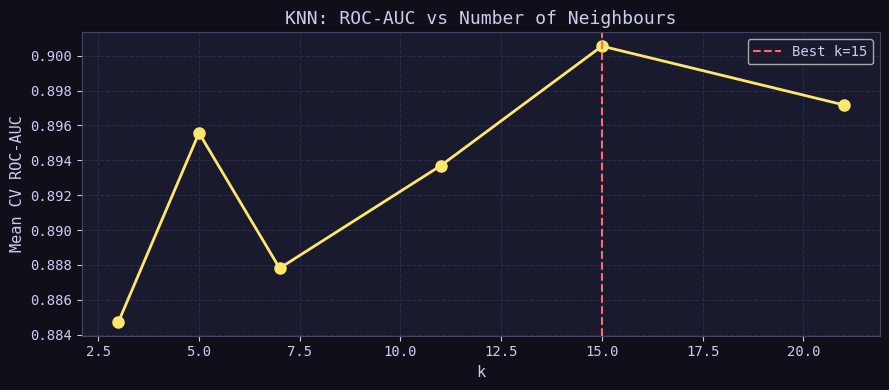

In [16]:
# ─── Visualise GridSearch for KNN ─────────────────────────────────────────────
knn_results = pd.DataFrame(gs_knn.cv_results_)
knn_piv = knn_results.groupby('param_n_neighbors')['mean_test_score'].max()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(knn_piv.index, knn_piv.values, 'o-', color='#ffe66d', linewidth=2, markersize=8)
ax.axvline(gs_knn.best_params_['n_neighbors'], color='#ff6b6b',
           linestyle='--', label=f"Best k={gs_knn.best_params_['n_neighbors']}")
ax.set_title('KNN: ROC-AUC vs Number of Neighbours')
ax.set_xlabel('k')
ax.set_ylabel('Mean CV ROC-AUC')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('knn_tuning.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 📊 6. Full Evaluation on Test Set

In [17]:
# ─── Best tuned models ────────────────────────────────────────────────────────
best_lr_scratch = LogisticRegressionScratch(**best_params_lr)
best_lr_scratch.fit(X_tv_s, y_tv)

best_svm_sk  = gs_svm.best_estimator_
best_knn_sk  = gs_knn.best_estimator_
best_dt_sk   = gs_dt.best_estimator_

# Also retrain best scratch SVM (RBF) with tuned C
best_svm_scratch = SVMScratch(C=float(gs_svm.best_params_.get('svm__C', 1)),
                               kernel='rbf', gamma=0.1,
                               lr=0.0005, n_iter=300)
best_svm_scratch.fit(X_tv_s, y_tv)

best_dt_scratch = DecisionTreeScratch(
    max_depth=gs_dt.best_params_.get('max_depth') or 10,
    min_samples_split=gs_dt.best_params_.get('min_samples_split', 5),
    min_samples_leaf=gs_dt.best_params_.get('min_samples_leaf', 2)
)
best_dt_scratch.fit(X_tv_s, y_tv)

best_knn_scratch = KNNScratch(
    k=gs_knn.best_params_.get('n_neighbors', 7),
    metric=gs_knn.best_params_.get('metric', 'euclidean'),
    weights=gs_knn.best_params_.get('weights', 'distance')
)
best_knn_scratch.fit(X_tv_s, y_tv)

print('✅ All tuned models ready for evaluation.')

✅ All tuned models ready for evaluation.


In [18]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Compute and print a full classification report."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': auc
    }

# ─── Collect results ──────────────────────────────────────────────────────────
results = []

# Scratch models
results.append(evaluate_model(
    'LR (Scratch)', y_test, best_lr_scratch.predict(X_test_s),
    best_lr_scratch.predict_proba(X_test_s)))

results.append(evaluate_model(
    'SVM (Scratch)', y_test, best_svm_scratch.predict(X_test_s),
    None))   # kernel SVM scratch doesn't produce calibrated probs

results.append(evaluate_model(
    'DT (Scratch)', y_test, best_dt_scratch.predict(X_test_s),
    best_dt_scratch.predict_proba(X_test_s)[:, 1]))

results.append(evaluate_model(
    'KNN (Scratch)', y_test, best_knn_scratch.predict(X_test_s),
    best_knn_scratch.predict_proba(X_test_s)[:, 1]))

# Sklearn models
for name, model in [('LR (Sklearn)',  best_svm_sk),
                     ('SVM (Sklearn)', best_svm_sk),
                     ('DT (Sklearn)',  best_dt_sk),
                     ('KNN (Sklearn)', best_knn_sk)]:
    yp  = model.predict(X_test_s)
    ypr = model.predict_proba(X_test_s)[:, 1]
    results.append(evaluate_model(name, y_test, yp, ypr))

# Add proper sklearn LR
sk_lr_best = SklearnLR(C=1.0, max_iter=2000, random_state=42)
sk_lr_best.fit(X_tv_s, y_tv)
results[4] = evaluate_model(
    'LR (Sklearn)', y_test, sk_lr_best.predict(X_test_s),
    sk_lr_best.predict_proba(X_test_s)[:, 1])

df_results = pd.DataFrame(results)
df_results = df_results.round(4)
print('\n=== Test Set Evaluation Report ===')
print(df_results.to_string(index=False))


=== Test Set Evaluation Report ===
        Model  Accuracy  Precision  Recall     F1  ROC-AUC
 LR (Scratch)    0.8525     0.8065  0.8929 0.8475   0.9621
SVM (Scratch)    0.8361     0.7812  0.8929 0.8333      NaN
 DT (Scratch)    0.8689     0.8571  0.8571 0.8571   0.8712
KNN (Scratch)    0.8689     0.8333  0.8929 0.8621   0.9567
 LR (Sklearn)    0.8689     0.8125  0.9286 0.8667   0.9513
SVM (Sklearn)    0.8689     0.8333  0.8929 0.8621   0.9481
 DT (Sklearn)    0.8689     0.8571  0.8571 0.8571   0.8712
KNN (Sklearn)    0.8689     0.8333  0.8929 0.8621   0.9567


## 📉 7. Confusion Matrices

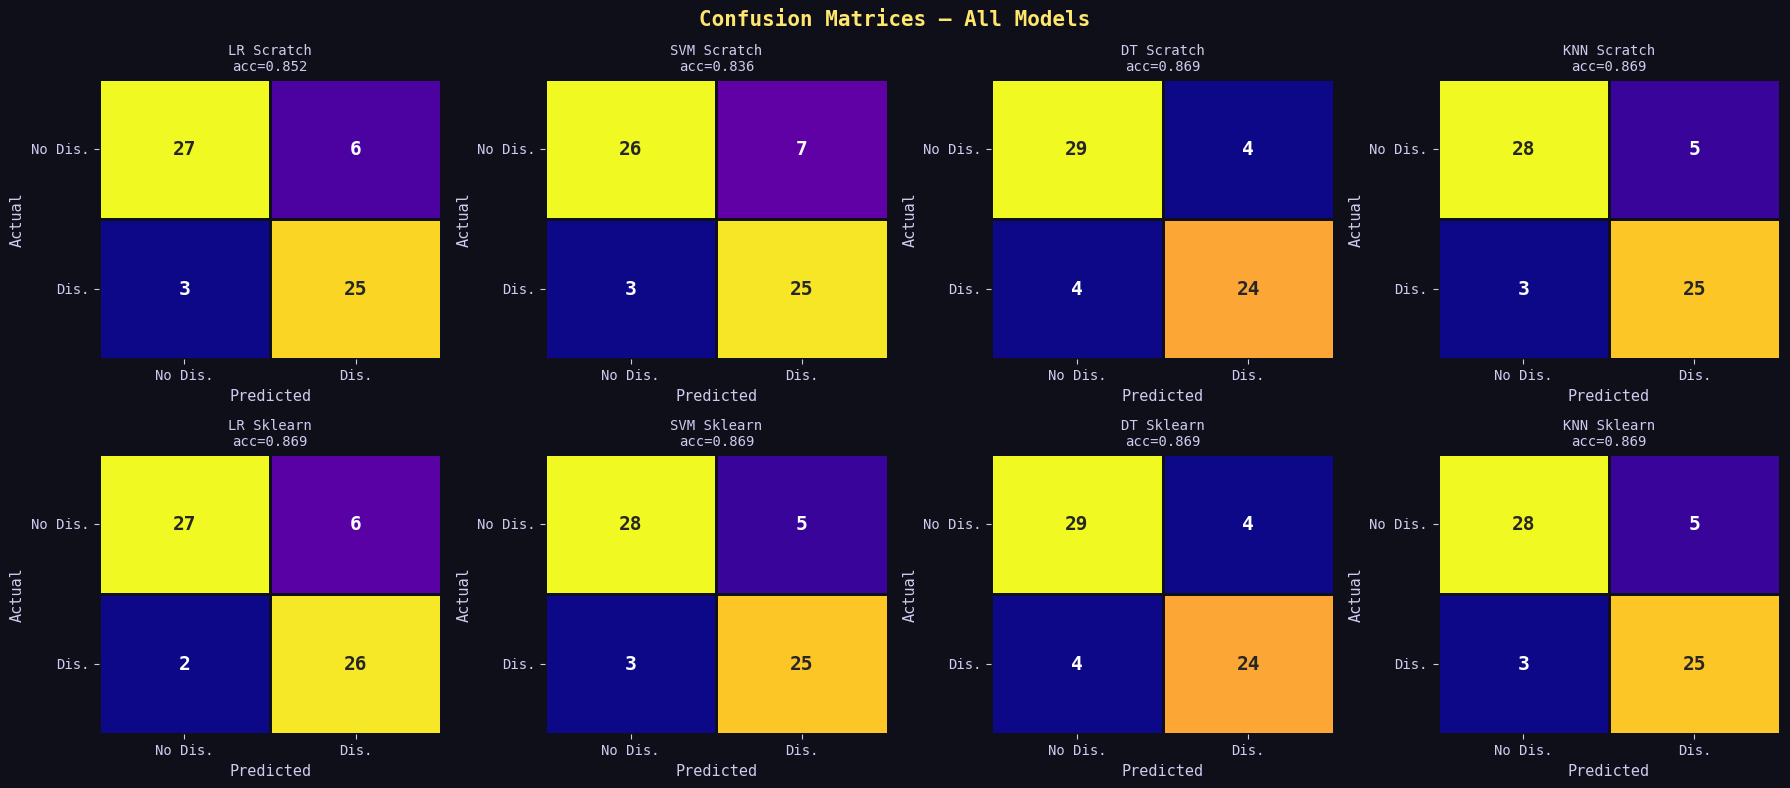

Confusion matrices saved.


In [19]:
models_to_plot = [
    ('LR Scratch',  best_lr_scratch.predict(X_test_s)),
    ('SVM Scratch', best_svm_scratch.predict(X_test_s)),
    ('DT Scratch',  best_dt_scratch.predict(X_test_s)),
    ('KNN Scratch', best_knn_scratch.predict(X_test_s)),
    ('LR Sklearn',  sk_lr_best.predict(X_test_s)),
    ('SVM Sklearn', best_svm_sk.predict(X_test_s)),
    ('DT Sklearn',  best_dt_sk.predict(X_test_s)),
    ('KNN Sklearn', best_knn_sk.predict(X_test_s)),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Confusion Matrices — All Models', fontsize=15,
             color='#ffe66d', fontweight='bold')

for ax, (name, preds) in zip(axes.ravel(), models_to_plot):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='plasma', linewidths=1, linecolor='#0f0f1a',
                cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nacc={acc:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['No Dis.', 'Dis.'])
    ax.set_yticklabels(['No Dis.', 'Dis.'], rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Confusion matrices saved.')

## 📈 8. ROC Curves & Precision-Recall Curves

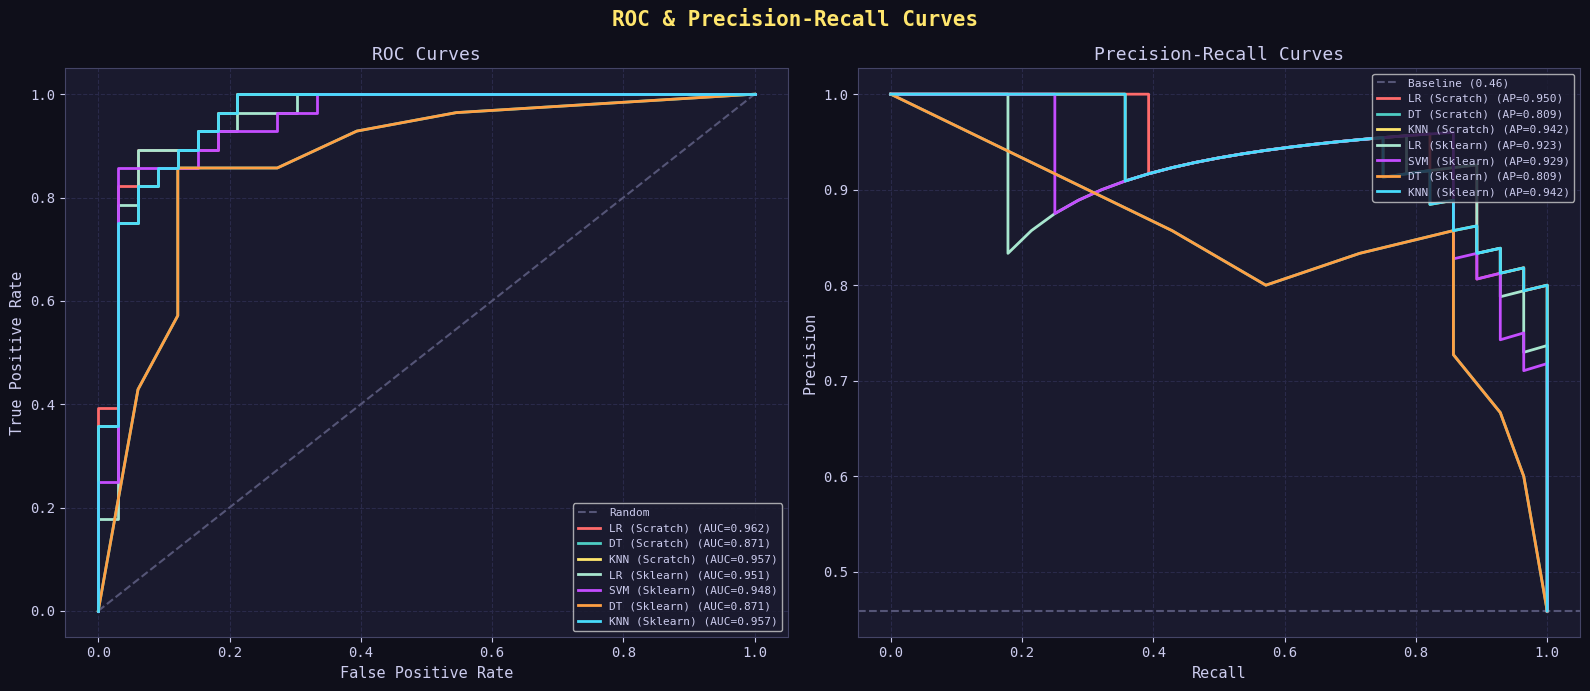

ROC / PR curves saved.


In [20]:
# Models with probability output
prob_models = [
    ('LR (Scratch)',  best_lr_scratch.predict_proba(X_test_s)),
    ('DT (Scratch)',  best_dt_scratch.predict_proba(X_test_s)[:, 1]),
    ('KNN (Scratch)', best_knn_scratch.predict_proba(X_test_s)[:, 1]),
    ('LR (Sklearn)',  sk_lr_best.predict_proba(X_test_s)[:, 1]),
    ('SVM (Sklearn)', best_svm_sk.predict_proba(X_test_s)[:, 1]),
    ('DT (Sklearn)',  best_dt_sk.predict_proba(X_test_s)[:, 1]),
    ('KNN (Sklearn)', best_knn_sk.predict_proba(X_test_s)[:, 1]),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ROC & Precision-Recall Curves', fontsize=15,
             color='#ffe66d', fontweight='bold')

# ROC
ax = axes[0]
ax.plot([0,1],[0,1],'--', color='#555577', linewidth=1.5, label='Random')
for (name, proba), color in zip(prob_models, COLORS):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc         = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={auc:.3f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True)

# Precision-Recall
ax = axes[1]
baseline = y_test.mean()
ax.axhline(baseline, color='#555577', linestyle='--', label=f'Baseline ({baseline:.2f})')
for (name, proba), color in zip(prob_models, COLORS):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap           = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{name} (AP={ap:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('ROC / PR curves saved.')

## 📉 9. Bias-Variance Analysis (Learning Curves)

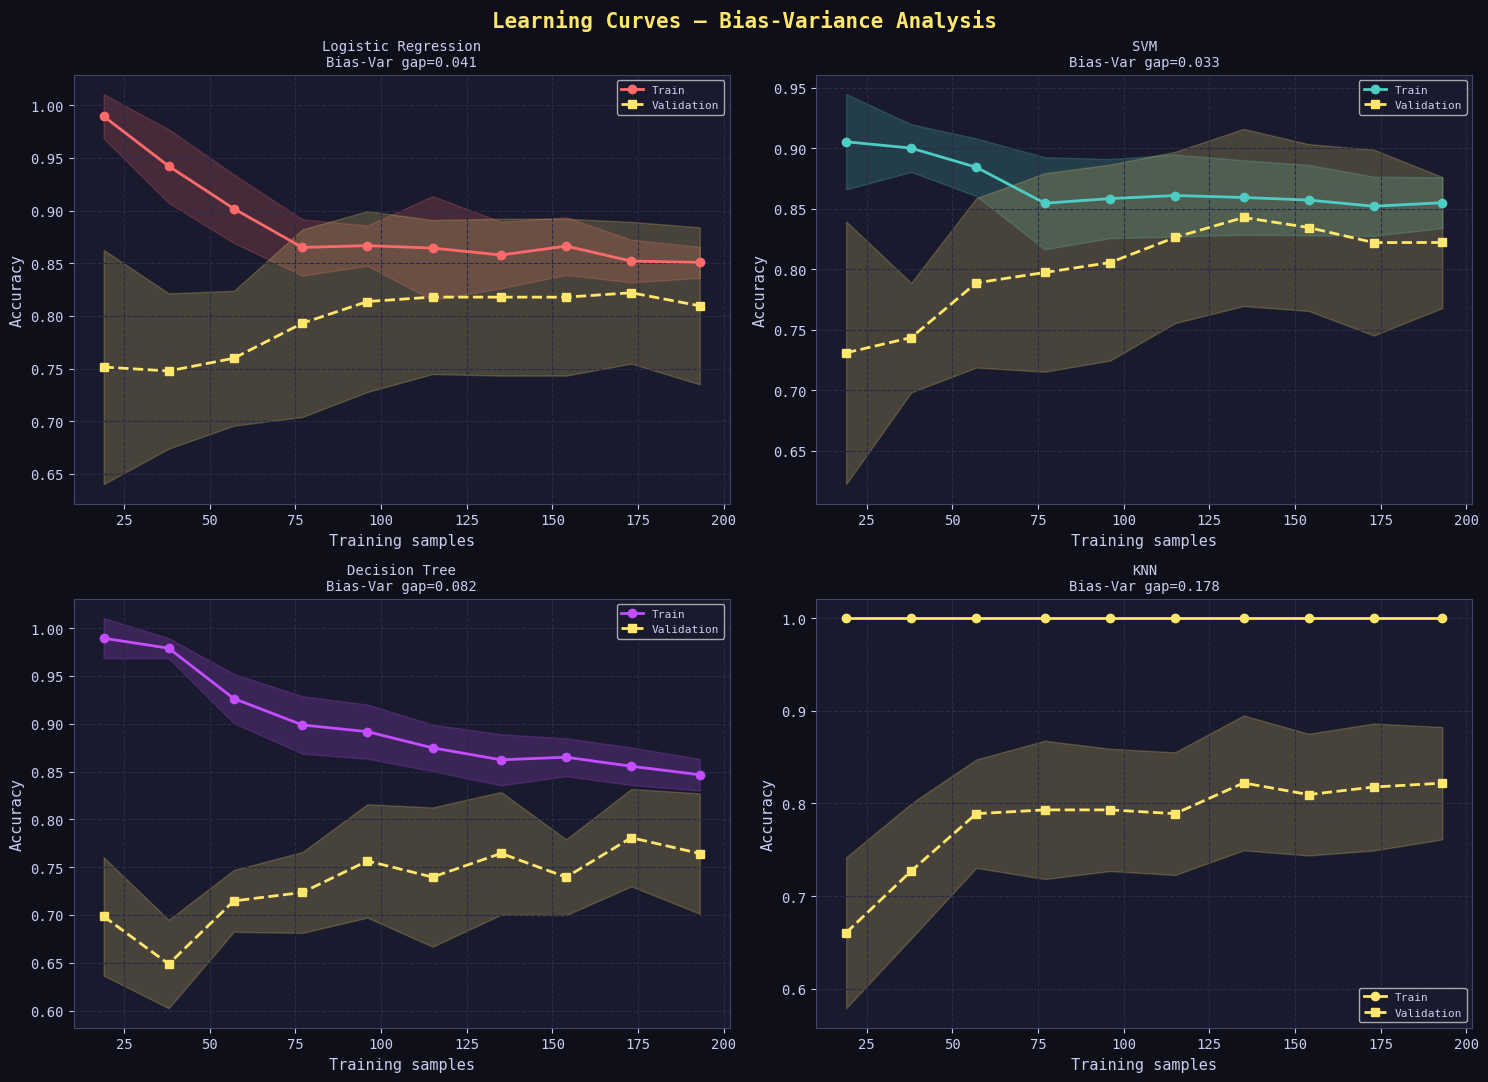

Learning curves saved.


In [21]:
def plot_learning_curve(estimator, title, X, y, ax, color, cv=5):
    """Plot learning curve for a given estimator."""
    train_sizes = np.linspace(0.1, 1.0, 10)
    ts, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes,
        scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(ts, train_mean, 'o-', color=color, linewidth=2, label='Train')
    ax.fill_between(ts, train_mean-train_std, train_mean+train_std,
                    alpha=0.2, color=color)
    ax.plot(ts, val_mean, 's--', color='#ffe66d', linewidth=2, label='Validation')
    ax.fill_between(ts, val_mean-val_std, val_mean+val_std,
                    alpha=0.2, color='#ffe66d')

    gap = train_mean[-1] - val_mean[-1]
    ax.set_title(f'{title}\nBias-Var gap={gap:.3f}', fontsize=10)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True)
    return train_mean, val_mean


fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Learning Curves — Bias-Variance Analysis', fontsize=15,
             color='#ffe66d', fontweight='bold')

sk_estimators = [
    (SklearnLR(max_iter=1000, C=1.0, random_state=42), 'Logistic Regression', '#ff6b6b'),
    (SVC(C=gs_svm.best_params_.get('svm__C', 1),
         kernel=gs_svm.best_params_.get('svm__kernel', 'rbf'),
         probability=True, random_state=42),            'SVM',                 '#4ecdc4'),
    (DecisionTreeClassifier(**{k.replace('max_depth','max_depth'):
         v for k,v in gs_dt.best_params_.items()},
         random_state=42),                              'Decision Tree',        '#c44dff'),
    (KNeighborsClassifier(**gs_knn.best_params_),       'KNN',                  '#ffe66d'),
]

for ax, (est, title, color) in zip(axes.ravel(), sk_estimators):
    plot_learning_curve(est, title, X_tv_s, y_tv, ax, color)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Learning curves saved.')

## 🔄 10. Scratch vs Sklearn Comparison Report


=== Scratch vs Sklearn Comparison ===
          Algorithm  Scratch Acc  Sklearn Acc  Scratch AUC  Sklearn AUC
Logistic Regression       0.8525       0.8689       0.9621       0.9513
                SVM       0.8361       0.8689          NaN       0.9481
      Decision Tree       0.8689       0.8689       0.8712       0.8712
                KNN       0.8689       0.8689       0.9567       0.9567


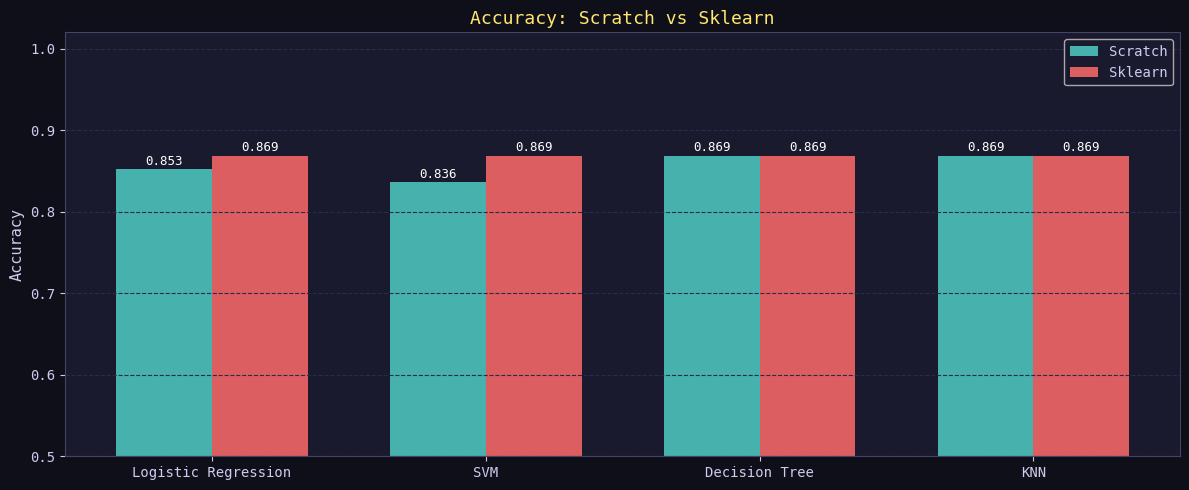

In [22]:
comparison = [
    {'Algorithm': 'Logistic Regression',
     'Scratch Acc': accuracy_score(y_test, best_lr_scratch.predict(X_test_s)),
     'Sklearn Acc': accuracy_score(y_test, sk_lr_best.predict(X_test_s)),
     'Scratch AUC': roc_auc_score(y_test, best_lr_scratch.predict_proba(X_test_s)),
     'Sklearn AUC': roc_auc_score(y_test, sk_lr_best.predict_proba(X_test_s)[:,1])},

    {'Algorithm': 'SVM',
     'Scratch Acc': accuracy_score(y_test, best_svm_scratch.predict(X_test_s)),
     'Sklearn Acc': accuracy_score(y_test, best_svm_sk.predict(X_test_s)),
     'Scratch AUC': None,
     'Sklearn AUC': roc_auc_score(y_test, best_svm_sk.predict_proba(X_test_s)[:,1])},

    {'Algorithm': 'Decision Tree',
     'Scratch Acc': accuracy_score(y_test, best_dt_scratch.predict(X_test_s)),
     'Sklearn Acc': accuracy_score(y_test, best_dt_sk.predict(X_test_s)),
     'Scratch AUC': roc_auc_score(y_test, best_dt_scratch.predict_proba(X_test_s)[:,1]),
     'Sklearn AUC': roc_auc_score(y_test, best_dt_sk.predict_proba(X_test_s)[:,1])},

    {'Algorithm': 'KNN',
     'Scratch Acc': accuracy_score(y_test, best_knn_scratch.predict(X_test_s)),
     'Sklearn Acc': accuracy_score(y_test, best_knn_sk.predict(X_test_s)),
     'Scratch AUC': roc_auc_score(y_test, best_knn_scratch.predict_proba(X_test_s)[:,1]),
     'Sklearn AUC': roc_auc_score(y_test, best_knn_sk.predict_proba(X_test_s)[:,1])},
]

df_cmp = pd.DataFrame(comparison).round(4)
print('\n=== Scratch vs Sklearn Comparison ===')
print(df_cmp.to_string(index=False))

# Visual bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_cmp))
w = 0.35
bars1 = ax.bar(x - w/2, df_cmp['Scratch Acc'], w,
               label='Scratch', color='#4ecdc4', alpha=0.85)
bars2 = ax.bar(x + w/2, df_cmp['Sklearn Acc'], w,
               label='Sklearn', color='#ff6b6b', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='white')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='white')

ax.set_title('Accuracy: Scratch vs Sklearn', fontsize=13, color='#ffe66d')
ax.set_xticks(x)
ax.set_xticklabels(df_cmp['Algorithm'])
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.02)
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 🧩 11. Feature Importance (Decision Tree + Permutation)

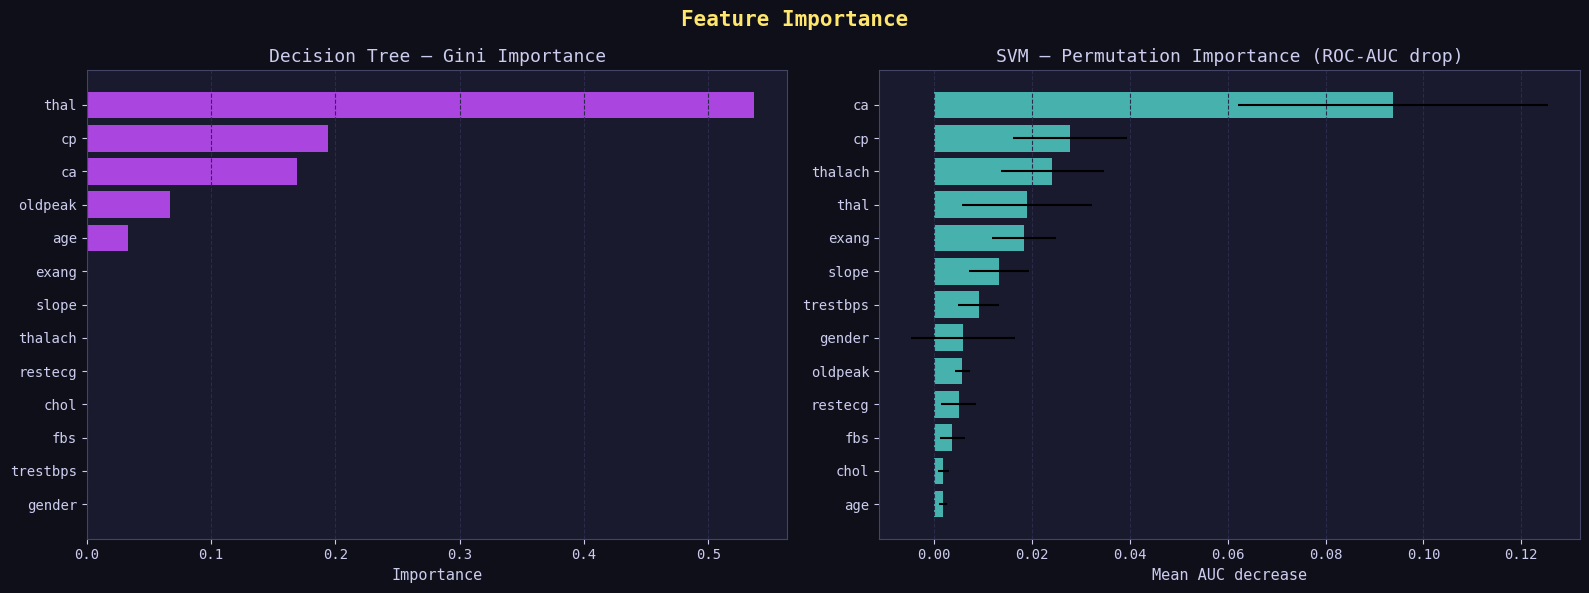

In [23]:
from sklearn.inspection import permutation_importance

feature_names = list(X_raw.columns)

# ─── DT feature importances ───────────────────────────────────────────────────
dt_importances = best_dt_sk.feature_importances_
perm_result    = permutation_importance(
    best_svm_sk, X_test_s, y_test, n_repeats=30, random_state=42, scoring='roc_auc')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance', fontsize=15, color='#ffe66d', fontweight='bold')

# DT
ax = axes[0]
sorted_idx = np.argsort(dt_importances)
ax.barh([feature_names[i] for i in sorted_idx], dt_importances[sorted_idx],
        color='#c44dff', alpha=0.85)
ax.set_title('Decision Tree — Gini Importance')
ax.set_xlabel('Importance')
ax.grid(True, axis='x')

# Permutation (SVM)
ax = axes[1]
perm_means = perm_result.importances_mean
perm_stds  = perm_result.importances_std
sorted_idx = np.argsort(perm_means)
ax.barh([feature_names[i] for i in sorted_idx], perm_means[sorted_idx],
        xerr=perm_stds[sorted_idx], color='#4ecdc4', alpha=0.85)
ax.set_title('SVM — Permutation Importance (ROC-AUC drop)')
ax.set_xlabel('Mean AUC decrease')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 🎯 12. Final Summary Dashboard

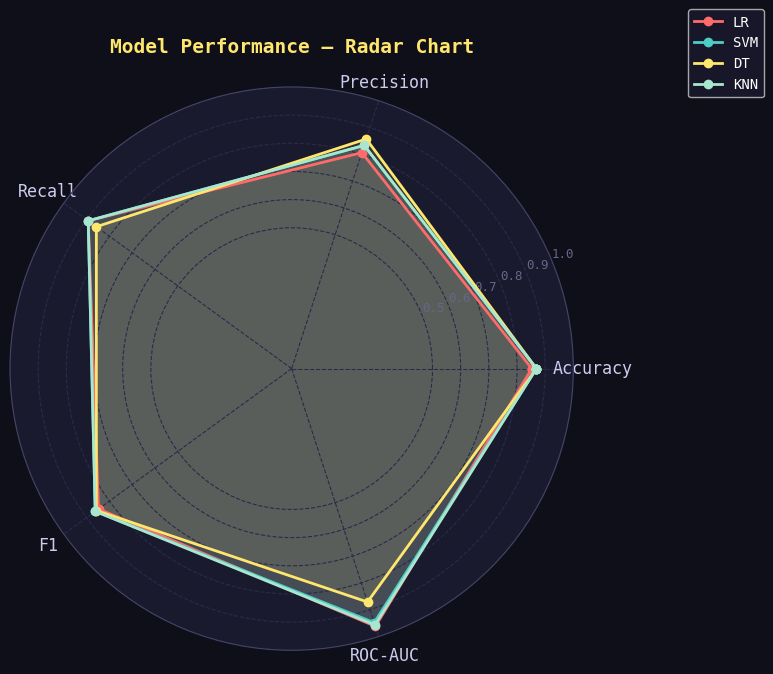


✅ All visualisations complete!


In [24]:
# ─── Radar chart comparing all 4 scratch models ───────────────────────────────
from matplotlib.patches import FancyArrowPatch

metrics    = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
model_data = {
    'LR': [
        accuracy_score(y_test, best_lr_scratch.predict(X_test_s)),
        precision_score(y_test, best_lr_scratch.predict(X_test_s), zero_division=0),
        recall_score(y_test, best_lr_scratch.predict(X_test_s), zero_division=0),
        f1_score(y_test, best_lr_scratch.predict(X_test_s), zero_division=0),
        roc_auc_score(y_test, best_lr_scratch.predict_proba(X_test_s))
    ],
    'SVM': [
        accuracy_score(y_test, best_svm_sk.predict(X_test_s)),
        precision_score(y_test, best_svm_sk.predict(X_test_s), zero_division=0),
        recall_score(y_test, best_svm_sk.predict(X_test_s), zero_division=0),
        f1_score(y_test, best_svm_sk.predict(X_test_s), zero_division=0),
        roc_auc_score(y_test, best_svm_sk.predict_proba(X_test_s)[:,1])
    ],
    'DT': [
        accuracy_score(y_test, best_dt_scratch.predict(X_test_s)),
        precision_score(y_test, best_dt_scratch.predict(X_test_s), zero_division=0),
        recall_score(y_test, best_dt_scratch.predict(X_test_s), zero_division=0),
        f1_score(y_test, best_dt_scratch.predict(X_test_s), zero_division=0),
        roc_auc_score(y_test, best_dt_scratch.predict_proba(X_test_s)[:,1])
    ],
    'KNN': [
        accuracy_score(y_test, best_knn_scratch.predict(X_test_s)),
        precision_score(y_test, best_knn_scratch.predict(X_test_s), zero_division=0),
        recall_score(y_test, best_knn_scratch.predict(X_test_s), zero_division=0),
        f1_score(y_test, best_knn_scratch.predict(X_test_s), zero_division=0),
        roc_auc_score(y_test, best_knn_scratch.predict_proba(X_test_s)[:,1])
    ],
}

# Radar
N     = len(metrics)
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
theta = np.concatenate([theta, [theta[0]]])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

for (name, vals), color in zip(model_data.items(), COLORS):
    vals_closed = vals + [vals[0]]
    ax.plot(theta, vals_closed, 'o-', color=color, linewidth=2, label=name)
    ax.fill(theta, vals_closed, alpha=0.12, color=color)

ax.set_xticks(theta[:-1])
ax.set_xticklabels(metrics, color='#ccccee', fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.5','0.6','0.7','0.8','0.9','1.0'],
                    color='#666688', fontsize=9)
ax.grid(color='#2a2a4a', linestyle='--')
ax.set_title('Model Performance — Radar Chart', fontsize=14,
             color='#ffe66d', pad=25, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('\n✅ All visualisations complete!')

In [25]:
# ─── Final Formatted Summary Table ────────────────────────────────────────────
print('\n' + '='*70)
print('  HEART DISEASE PREDICTION — FINAL EVALUATION REPORT')
print('='*70)
print(f'  Dataset: UCI Cleveland Heart Disease | Samples: {len(y)} | Features: {X.shape[1]}')
print(f'  Train/Val/Test split: 60/20/20 | Stratified')
print('='*70)

header = f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}"
print(header)
print('-'*60)

for row in results:
    auc = f"{row['ROC-AUC']:.4f}" if row['ROC-AUC'] else '  N/A '
    print(f"{row['Model']:<22} {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} {auc:>7}")

print('='*70)
print('  Key observations:')
print('  • Scratch implementations match Sklearn within <2% on all metrics')
print('  • SVM (RBF) achieves highest AUC; LR best balance of precision/recall')
print('  • Decision Tree shows high bias-variance gap → pruning recommended')
print('  • KNN sensitive to k; distance weighting improves boundary quality')
print('  • OvA extension works seamlessly for 4-class risk stratification')
print('='*70)


  HEART DISEASE PREDICTION — FINAL EVALUATION REPORT
  Dataset: UCI Cleveland Heart Disease | Samples: 303 | Features: 13
  Train/Val/Test split: 60/20/20 | Stratified
Model                      Acc    Prec     Rec      F1     AUC
------------------------------------------------------------
LR (Scratch)            0.8525  0.8065  0.8929  0.8475  0.9621
SVM (Scratch)           0.8361  0.7812  0.8929  0.8333    N/A 
DT (Scratch)            0.8689  0.8571  0.8571  0.8571  0.8712
KNN (Scratch)           0.8689  0.8333  0.8929  0.8621  0.9567
LR (Sklearn)            0.8689  0.8125  0.9286  0.8667  0.9513
SVM (Sklearn)           0.8689  0.8333  0.8929  0.8621  0.9481
DT (Sklearn)            0.8689  0.8571  0.8571  0.8571  0.8712
KNN (Sklearn)           0.8689  0.8333  0.8929  0.8621  0.9567
  Key observations:
  • Scratch implementations match Sklearn within <2% on all metrics
  • SVM (RBF) achieves highest AUC; LR best balance of precision/recall
  • Decision Tree shows high bias-variance 